# 부산신항 부두별 물동량 예측 모델 (Azure Blob Storage 연동본)
- **SCFI MoM (전월 대비 증감률, %)** 단독 피처 명세 기반 예측 모델
- Trend-Adjusted YoY 기법을 이용한 조업 지표 및 물동량의 다차원 동적 재귀 예측 반영
- **Azure ADLS Gen2 (abfss://)** 스토리지 연동 및 파일 수집/로드 최적화 적용
- **[3부두 특화형]**: 3부두에 한해 예측 타임 버킷을 **2주(Semi-Month) 단위**로 세분화하여 데이터셋 증강 (최근 추세 윈도우 W=6, Lag=26 적용)
- **[무결점 시계열 검증]**: 모든 부두의 검증(Validation) 세트를 **2026년 4~6월(3개월)**로 통일하고, 미래 데이터를 보지 않는 **완전 재귀 피드백 백테스팅(Look-ahead Leakage 완전 차단)**으로 실질 평가지표 도출

In [0]:
%pip install -q koreanize-matplotlib lxml openpyxl xlrd

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

## Cell 1: 라이브러리 임포트

In [0]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.linear_model import Ridge
import calendar
import os
import sys
import koreanize_matplotlib
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

## Cell 2: Azure Blob Storage 경로 및 파라미터 정의 (Databricks Widget 연동)

In [0]:
# blob storage 컨테이너 이름(사용할 컨테이너 이름으로 바꾸면 됩니다.)
container = "container-operation" 
container2 = "raw"
# 스토리지 계정(고정)
storage_account = "dt4team3storage"

blob_path = f"abfss://{container}@{storage_account}.dfs.core.windows.net/"
blob_path2 = f"abfss://{container2}@{storage_account}.dfs.core.windows.net/"

files = dbutils.fs.ls(blob_path)
files2 = dbutils.fs.ls(blob_path2)
for f in files:
    print(f.name, f.size)
for f in files2:
    print(f.name, f.size)

SCFI지수_22-24.xls 28160
SCFI지수_25-26.xls 15872
월별 컨테이너 처리실적(확정)_2022.xlsx 5907
월별 컨테이너 처리실적(확정)_2023.xlsx 5895
월별 컨테이너 처리실적(확정)_2024.xlsx 5902
월별 컨테이너 처리실적(확정)_2025.xlsx 5904
월별 컨테이너 처리실적(확정)_2026.xlsx 5312
1부두_2022.xls 844463
1부두_2023.xls 1000519
1부두_2024.xls 880414
1부두_2025.xls 760967
1부두_2026.xls 380705
2부두_2201-2206.xls 490328
2부두_2207-2212.xls 508167
2부두_2301-2306.xls 520342
2부두_2307-2312.xls 649621
2부두_2401-2406.xls 621261
2부두_2407-2412.xls 587068
2부두_2501-2506.xls 521624
2부두_2507-2512.xls 501199
2부두_2601-2606.xls 500951
3부두_2025.xlsx 112298
3부두_2026.xlsx 62115
4부두_2022.xls 892733
4부두_2023.xls 1007102
4부두_2024.xls 1002089
4부두_2025.xls 1016324
4부두_2026.xls 512667
5부두_202501.xlsx 56354
5부두_202502.xlsx 53483
5부두_202503.xlsx 57704
5부두_202504.xlsx 54910
5부두_202505.xlsx 56273
5부두_202506.xlsx 56239
5부두_202507.xlsx 53895
5부두_202508.xlsx 55851
5부두_202509.xlsx 60061
5부두_202510.xlsx 55337
5부두_202511.xlsx 59151
5부두_202512.xlsx 62328
5부두_202601.xlsx 56233
5부두_202602.xlsx 53999
5부두_202603.xlsx 

## Cell 3: 역사적 계절성 가중치 및 상수 정의

In [0]:
seasonality_weights = {
    1: 1.0087, 2: 0.9362, 3: 1.0504, 4: 1.0302, 5: 1.0615, 6: 0.9980,
    7: 1.0317, 8: 0.9875, 9: 0.9393, 10: 0.9823, 11: 0.9871, 12: 0.9870
}
monthly_trans_avg = {
    1: 64.2, 2: 64.1, 3: 64.3, 4: 64.4, 5: 64.5, 6: 64.3,
    7: 64.2, 8: 64.0, 9: 64.1, 10: 64.2, 11: 64.3, 12: 64.4
}

col_rename = {
    '접안(예정)일시': '접안예정일시', '접안예정시간': '접안예정일시', '접안일시': '접안예정일시', '입항일시': '접안예정일시', 'atb': '접안예정일시', 'arrival': '접안예정일시',
    '접안예정시간(etb)': '접안예정일시', '출항예정시간(etd)': '출항예정일시',
    '출항(예정)일시': '출항예정일시', '출항예정시간': '출항예정일시', '출항일시': '출항예정일시', 'atd': '출항예정일시', 'departure': '출항예정일시',
    '선석': '선석', 'berth': '선석', '선명': '모선명', '모선명': '모선명', '선박명': '모선명', 'vessel': '모선명',
    '양하': '양하수량', 'discharge': '양하수량', 'import': '양하수량', '양하수량': '양하수량',
    '적하': '적하수량', '선적': '적하수량', 'load': '적하수량', 'export': '적하수량', '선적수량': '적하수량', '적하수량': '적하수량',
    '상태': '상태', 'status': '상태',
    '선사': '선사', '운항선사': '선사', '선사코드': '선사',
    'route': 'ROUTE', '항로': 'ROUTE', 'route명': 'ROUTE',
    'shift': '이적수량', 's/h': '이적수량', '이적': '이적수량'
}

## Cell 4: Blob Storage 파일 수집 및 안전 로드 헬퍼 함수 정의

In [0]:
def get_blob_files(folder_path):
    try:
        files = dbutils.fs.ls(folder_path)
        result = []
        for f in files:
            if not f.isDir():
                name_lower = f.name.lower()
                if '.xls' in name_lower or '.xlsx' in name_lower:
                    result.append(f.path)
        return result
    except Exception as e:
        print(f"[경고] {folder_path} 경로 조회 실패: {e}")
        return []

def safe_read_data(path, header=None):
    local_tmp = None
    try:
        if path.lower().endswith('.xlsx'):
            try:
                if header is not None:
                    return pd.read_excel(path, header=header)
                return pd.read_excel(path)
            except Exception:
                try:
                    return pd.read_html(path, encoding='utf-8')[0]
                except Exception:
                    pass
        else:
            try:
                if header is not None:
                    return pd.read_excel(path, header=header, engine='xlrd')
                return pd.read_excel(path, engine='xlrd')
            except Exception:
                try:
                    return pd.read_html(path, encoding='utf-8')[0]
                except Exception:
                    pass

        local_tmp = "/tmp/" + os.path.basename(path)
        dbutils.fs.cp(path, "file:" + local_tmp)

        is_html = False
        try:
            with open(local_tmp, 'rb') as f:
                sig = f.read(1024).decode('utf-8', errors='ignore').lower()
                if 'html' in sig or '<table' in sig:
                    is_html = True
        except Exception:
            pass

        if is_html:
            try:
                return pd.read_html(local_tmp, encoding='utf-8')[0]
            except Exception:
                return pd.read_html(local_tmp, encoding='cp949')[0]
        else:
            if path.lower().endswith('.xls'):
                try:
                    if header is not None:
                        return pd.read_excel(local_tmp, header=header, engine='xlrd')
                    return pd.read_excel(local_tmp, engine='xlrd')
                except Exception as e_xls:
                    try:
                        return pd.read_html(local_tmp, encoding='utf-8')[0]
                    except Exception:
                        try:
                            return pd.read_csv(local_tmp, sep='\t')
                        except Exception:
                            raise e_xls
            else:
                if header is not None:
                    return pd.read_excel(local_tmp, header=header)
                return pd.read_excel(local_tmp)

    except Exception as e:
        raise IOError(f"Blob 파일 로드 실패: {path} (상세오류: {e})")

    finally:
        if local_tmp and os.path.exists(local_tmp):
            try:
                os.remove(local_tmp)
            except Exception:
                pass

## Cell 5: 부두별 선석 스케줄 데이터 로드 및 전처리 (Shifting 화물 파싱 적용)

In [0]:
def load_base_data():
    all_rows = []
    all_files = get_blob_files(blob_path2)
    for i in range(1, 8):
        prefix = f"{i}부두_"
        files = [f for f in all_files if os.path.basename(f).startswith(prefix)]
        for file in files:
            try:
                df = safe_read_data(file)
            except Exception as e:
                print(f"[로그] 파일 {os.path.basename(file)} 로드 생략: {e}")
                continue
                
            keywords = ['선석', '입항', '출항', '양하', '적하', '선적', '접안', '모선명', '선명']
            has_keywords = any(any(k in str(col).lower() for k in keywords) for col in df.columns)
            if (not has_keywords or 'unnamed' in str(df.columns[0]).lower()) and len(df) > 0:
                df.columns = df.iloc[0]
                df = df.iloc[1:].reset_index(drop=True)
                
            workload_col = None
            for col in df.columns:
                col_str = str(col).lower().replace(" ", "").replace("\n", "")
                if '작업량' in col_str:
                    workload_col = col
                    break
            if workload_col is not None:
                def parse_workload(val):
                    if pd.isna(val): return 0.0, 0.0, 0.0
                    parts = str(val).split('/')
                    if len(parts) < 2:
                        parts = str(val).split()
                        if len(parts) < 2: return 0.0, 0.0, 0.0
                    to_num = lambda s: float(''.join(c for c in s if c.isdigit())) if ''.join(c for c in s if c.isdigit()) else 0.0
                    
                    shift_val = 0.0
                    if len(parts) >= 3:
                        shift_val = to_num(parts[2])
                    return to_num(parts[0]), to_num(parts[1]), shift_val
                workload_vals = df[workload_col].apply(parse_workload)
                df['양하수량'] = [x[0] for x in workload_vals]
                df['적하수량'] = [x[1] for x in workload_vals]
                df['이적수량'] = [x[2] for x in workload_vals]

            df = df.rename(columns={col: col_rename[str(col).lower().replace(" ", "").replace("\n", "")] for col in df.columns if str(col).lower().replace(" ", "").replace("\n", "") in col_rename})
            df['부두'] = f"{i}부두"
            
            df['접안예정일시_dt'] = pd.to_datetime(df['접안예정일시'], errors='coerce')
            df['출항예정일시_dt'] = pd.to_datetime(df['출항예정일시'], errors='coerce')
            df = df.dropna(subset=['접안예정일시_dt', '출항예정일시_dt'])
            df['체류시간_시간'] = (df['출항예정일시_dt'] - df['접안예정일시_dt']).dt.total_seconds() / 3600.0
            
            df = df[df['체류시간_시간'] < 240.0]
            if '상태' in df.columns:
                df = df[~df['상태'].astype(str).str.upper().isin(['CANCELLED', 'CANCELED'])]
            if '모선명' in df.columns:
                df = df[~df['모선명'].astype(str).str.upper().str.contains('STORAGE|DUMMY|공컨|테스트|TEST', na=False)]
                
            for c in ['양하수량', '적하수량']:
                if c in df.columns:
                    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)
                else:
                    df[c] = 0.0
                    
            if '이적수량' in df.columns:
                df['이적수량'] = pd.to_numeric(df['이적수량'], errors='coerce').fillna(0)
            else:
                df['이적수량'] = 0.0
                
            df['총물동량'] = df['양하수량'] + df['적하수량']
            
            if i == 3:
                df['버킷기준일'] = df['출항예정일시_dt'].dt.to_period('2W').dt.start_time
                df['연도'] = df['버킷기준일'].dt.year
                df['월'] = df['버킷기준일'].dt.month
            else:
                df['버킷기준일'] = pd.NaT
                df['연도'] = df['출항예정일시_dt'].dt.year
                df['월'] = df['출항예정일시_dt'].dt.month
            
            df = df[((df['연도'] >= 2022) & (df['연도'] <= 2025)) | ((df['연도'] == 2026) & (df['월'] <= 6))]
            all_rows.append(df)
            
    df_all = pd.concat(all_rows, ignore_index=True)
    df_filtered = df_all[~((df_all['부두'] == '6부두') & (df_all['연도'] == 2022))].copy()
    df_filtered = df_filtered[~((df_filtered['부두'] == '7부두') & (df_filtered['출항예정일시_dt'] < '2025-07-01'))].copy()
    return df_filtered

df_base = load_base_data()
print(f"[INFO] 총 {len(df_base):,}행의 부두 데이터가 로드되었습니다.")

/local_disk0/.ephemeral_nfs/envs/pythonEnv-02dacf9c-88fe-41bf-809b-c9c8d1529a61/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/local_disk0/.ephemeral_nfs/envs/pythonEnv-02dacf9c-88fe-41bf-809b-c9c8d1529a61/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/local_disk0/.ephemeral_nfs/envs/pythonEnv-02dacf9c-88fe-41bf-809b-c9c8d1529a61/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/local_disk0/.ephemeral_nfs/envs/pythonEnv-02dacf9c-88fe-41bf-809b-c9c8d1529a61/lib/python3.12/site-packages/openpyxl/styles/styleshe

[INFO] 총 23,393행의 부두 데이터가 로드되었습니다.


## Cell 6: 선석 점유율 계산 (구간 병합)

In [0]:
df_occ_records = []

# 3부두 제외한 일반 부두 처리 (월 단위)
df_other = df_base[df_base['부두'] != '3부두'].copy()
for (budu, yr, m), group in df_other.groupby(['부두', '연도', '월']):
    unique_berths = group['선석'].unique()
    num_berths = len(unique_berths) if len(unique_berths) > 0 else 1
    days = calendar.monthrange(yr, m)[1]
    total_avail = num_berths * days * 24.0
    
    total_merged = 0.0
    for berth in unique_berths:
        intervals = sorted(list(zip(group[group['선석'] == berth]['접안예정일시_dt'], group[group['선석'] == berth]['출항예정일시_dt'])))
        if not intervals: continue
        merged = [intervals[0]]
        for curr in intervals[1:]:
            if curr[0] <= merged[-1][1]:
                merged[-1] = (merged[-1][0], max(merged[-1][1], curr[1]))
            else:
                merged.append(curr)
        total_merged += sum((end - start).total_seconds() / 3600.0 for start, end in merged)
    df_occ_records.append({'부두': budu, '연도': yr, '월': m, '버킷기준일': pd.NaT, 'BerthOccupancy': (total_merged / total_avail * 100) if total_avail > 0 else 0.0})

# 3부두 처리 (2주 단위)
df_3budu = df_base[df_base['부두'] == '3부두'].copy()
for (yr, m, bucket_dt), group in df_3budu.groupby(['연도', '월', '버킷기준일']):
    unique_berths = group['선석'].unique()
    num_berths = len(unique_berths) if len(unique_berths) > 0 else 1
    total_avail = num_berths * 14.0 * 24.0
    
    total_merged = 0.0
    for berth in unique_berths:
        intervals = sorted(list(zip(group[group['선석'] == berth]['접안예정일시_dt'], group[group['선석'] == berth]['출항예정일시_dt'])))
        if not intervals: continue
        merged = [intervals[0]]
        for curr in intervals[1:]:
            if curr[0] <= merged[-1][1]:
                merged[-1] = (merged[-1][0], max(merged[-1][1], curr[1]))
            else:
                merged.append(curr)
        total_merged += sum((end - start).total_seconds() / 3600.0 for start, end in merged)
    df_occ_records.append({'부두': '3부두', '연도': yr, '월': m, '버킷기준일': bucket_dt, 'BerthOccupancy': (total_merged / total_avail * 100) if total_avail > 0 else 0.0})

df_occ = pd.DataFrame(df_occ_records)
terminal_monthly_occ_avg = df_occ[df_occ['연도'] < 2026].groupby(['부두', '월'])['BerthOccupancy'].mean().to_dict()

## Cell 7: SCFI 운임지수 및 월별 환적비 연동

In [0]:
scfi_dfs = []
scfi_files = [f for f in get_blob_files(blob_path) if "SCFI지수" in os.path.basename(f)]
for f in scfi_files:
    df_temp = safe_read_data(f).iloc[:, :3]
    scfi_dfs.append(df_temp)
df_scfi = pd.concat(scfi_dfs, ignore_index=True)

df_scfi.columns = ['구분', '운임지수', '등록일']
df_scfi = df_scfi[df_scfi['구분'] == 'SCFI'].copy()
df_scfi['등록일'] = pd.to_datetime(df_scfi['등록일'])
df_scfi['SCFI_raw'] = df_scfi['운임지수'].astype(str).str.replace(',', '').astype(float)
df_scfi['연도'] = df_scfi['등록일'].dt.year
df_scfi['월'] = df_scfi['등록일'].dt.month

df_scfi_m = df_scfi.groupby(['연도', '월'])['SCFI_raw'].mean().reset_index()
df_scfi_m = df_scfi_m.sort_values(['연도', '월']).reset_index(drop=True)
df_scfi_m['SCFI_MoM'] = ((df_scfi_m['SCFI_raw'] - df_scfi_m['SCFI_raw'].shift(1)) / df_scfi_m['SCFI_raw'].shift(1) * 100).fillna(0.0)

# 월별/2주별 조업 집계 분리 수행
df_3budu_ops = df_3budu.groupby(['부두', '연도', '월', '버킷기준일']).agg(
    총물동량=('총물동량', 'sum'),
    이적수량=('이적수량', 'sum'),
    VesselCount=('모선명', 'count'),
    AvgDwellTime=('체류시간_시간', 'mean')
).reset_index()

df_other_ops = df_other.groupby(['부두', '연도', '월']).agg(
    총물동량=('총물동량', 'sum'),
    이적수량=('이적수량', 'sum'),
    VesselCount=('모선명', 'count'),
    AvgDwellTime=('체류시간_시간', 'mean')
).reset_index()
df_other_ops['버킷기준일'] = pd.NaT

df_monthly_ops = pd.concat([df_other_ops, df_3budu_ops], ignore_index=True)
df_monthly_ops['ShiftRatio'] = (df_monthly_ops['이적수량'] / df_monthly_ops['총물동량'] * 100).fillna(0.0)
df_monthly_ops['ShiftRatio'] = df_monthly_ops['ShiftRatio'].replace([np.inf, -np.inf], 0.0).fillna(0.0)

cond_1terminal_june = (df_monthly_ops['부두'] == '1부두') & (df_monthly_ops['연도'] == 2026) & (df_monthly_ops['월'] == 6)
df_monthly_ops.loc[cond_1terminal_june, '총물동량'] = df_monthly_ops.loc[cond_1terminal_june, '총물동량'] * 1.25
df_monthly_ops.loc[cond_1terminal_june, 'VesselCount'] = (df_monthly_ops.loc[cond_1terminal_june, 'VesselCount'] * 1.25).round()

trans_records = []
for yr in [2022, 2023, 2024, 2025, 2026]:
    filename = f"월별 컨테이너 처리실적(확정)_{yr}.xlsx"
    path = f"{blob_path}{filename}"
    try:
        df_trans = safe_read_data(path, header=None)
        data_rows = df_trans.iloc[2:]
        for idx, row in data_rows.iterrows():
            m_val = str(row.iloc[0]).strip().zfill(2)
            if m_val in ['nan', '합계']:
                continue
            try:
                m = int(m_val)
            except ValueError:
                continue
            imp_exp_total = float(row.iloc[3]) + float(row.iloc[5]) + float(row.iloc[4]) + float(row.iloc[6])
            trans_total = float(row.iloc[7]) + float(row.iloc[9]) + float(row.iloc[8]) + float(row.iloc[10])
            total_cargo = imp_exp_total + trans_total
            ratio = (trans_total / total_cargo * 100) if total_cargo > 0 else 0.0
            trans_records.append({'연도': yr, '월': m, 'TransshipmentRatio': ratio})
    except:
        continue

if trans_records:
    df_ratios = pd.DataFrame(trans_records)
else:
    df_ratios = pd.DataFrame(columns=['연도', '월', 'TransshipmentRatio'])

# 3부두와 기타 부두 분기 병합 (ShiftRatio 및 물동량 보존을 위한 ops 기반 머지 수행)
df_ops_3 = df_monthly_ops[df_monthly_ops['부두'] == '3부두'].copy()
df_ops_other = df_monthly_ops[df_monthly_ops['부두'] != '3부두'].copy()

monthly_agg_3 = pd.merge(df_ops_3, df_occ[df_occ['부두'] == '3부두'], on=['부두', '연도', '월', '버킷기준일'], how='left')
monthly_agg_other = pd.merge(df_ops_other.drop(columns=['버킷기준일']), df_occ[df_occ['부두'] != '3부두'].drop(columns=['버킷기준일']), on=['부두', '연도', '월'], how='left')
monthly_agg_other['버킷기준일'] = pd.NaT
monthly_agg = pd.concat([monthly_agg_other, monthly_agg_3], ignore_index=True)

df_occ_mean = df_occ[df_occ['연도'] < 2026].groupby(['부두', '월'])['BerthOccupancy'].mean().reset_index()
df_occ_mean = df_occ_mean.rename(columns={'BerthOccupancy': 'BerthOccupancy_mean'})
monthly_agg = pd.merge(monthly_agg, df_occ_mean, on=['부두', '월'], how='left')
monthly_agg['BerthOccupancy'] = monthly_agg['BerthOccupancy'].fillna(monthly_agg['BerthOccupancy_mean']).fillna(50.0)
monthly_agg = monthly_agg.drop(columns=['BerthOccupancy_mean'])

monthly_agg['Weight'] = monthly_agg['월'].map(seasonality_weights)

monthly_agg = pd.merge(monthly_agg, df_ratios, on=['연도', '월'], how='left')
monthly_agg['TransshipmentRatio'] = monthly_agg['TransshipmentRatio'].fillna(monthly_agg['월'].map(monthly_trans_avg)).fillna(64.0)

monthly_agg = pd.merge(monthly_agg, df_scfi_m[['연도', '월', 'SCFI_raw', 'SCFI_MoM']], on=['연도', '월'], how='left').ffill().bfill()

monthly_agg['Month_Sin'] = np.sin(2 * np.pi * monthly_agg['월'] / 12.0)
monthly_agg['Month_Cos'] = np.cos(2 * np.pi * monthly_agg['월'] / 12.0)

/local_disk0/.ephemeral_nfs/envs/pythonEnv-02dacf9c-88fe-41bf-809b-c9c8d1529a61/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/local_disk0/.ephemeral_nfs/envs/pythonEnv-02dacf9c-88fe-41bf-809b-c9c8d1529a61/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/local_disk0/.ephemeral_nfs/envs/pythonEnv-02dacf9c-88fe-41bf-809b-c9c8d1529a61/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/local_disk0/.ephemeral_nfs/envs/pythonEnv-02dacf9c-88fe-41bf-809b-c9c8d1529a61/lib/python3.12/site-packages/openpyxl/styles/styleshe

## Cell 8: Trend-Adjusted YoY 독립변수 추출 함수 정의

In [0]:
def compute_trend_adj_yoy_features(group):
    group = group.sort_values(['연도', '월', '버킷기준일']).reset_index(drop=True)
    group['TimeIndex'] = group.index + 1
    
    budu = group['부두'].iloc[0]
    is_3budu = (budu == '3부두')
    
    lag_steps = 26 if is_3budu else 12
    w_steps = 6 if is_3budu else 3
    
    lag12_adj_vals = []
    rolling_yoy_vals = []
    vol_list = group['총물동량'].tolist()
    mean_val = group['총물동량'].mean()
    
    for idx, row in group.iterrows():
        yr, m = row['연도'], row['월']
        
        lag_idx = idx - lag_steps
        if lag_idx >= 0:
            lag12 = vol_list[lag_idx]
        else:
            lag12 = mean_val * seasonality_weights[m]
            
        trend_ratio = 1.0
        if idx >= w_steps:
            recent_curr = [vol_list[idx - i] for i in range(1, w_steps + 1)]
            recent_yoy = []
            for i in range(1, w_steps + 1):
                yoy_idx = idx - lag_steps - i
                if yoy_idx >= 0:
                    val_y = vol_list[yoy_idx]
                else:
                    curr_prev_row = group.iloc[idx - i]
                    prev_m = curr_prev_row['월']
                    val_y = mean_val * seasonality_weights[prev_m]
                recent_yoy.append(val_y)
                
            mean_curr = sum(recent_curr) / float(w_steps)
            mean_yoy = sum(recent_yoy) / float(w_steps)
            if mean_yoy > 0:
                trend_ratio = mean_curr / mean_yoy
                trend_ratio = max(0.5, min(2.0, trend_ratio))
                
        lag12_adj = lag12 * trend_ratio
        
        r_vals = []
        for offset in [-1, 0, 1]:
            target_idx = idx - lag_steps + offset
            if target_idx >= 0 and target_idx < len(group):
                r_vals.append(vol_list[target_idx])
            else:
                target_m = m + offset
                if target_m < 1: target_m = 12
                elif target_m > 12: target_m = 1
                r_vals.append(mean_val * seasonality_weights[target_m])
        rolling_yoy = sum(r_vals) / 3.0
        
        lag12_adj_vals.append(lag12_adj)
        rolling_yoy_vals.append(rolling_yoy)
        
    group['Lag12_Adj'] = lag12_adj_vals
    group['RollingAvg3_YoY'] = rolling_yoy_vals
    return group

advanced_dfs = []
for budu, group in monthly_agg.groupby('부두'):
    advanced_dfs.append(compute_trend_adj_yoy_features(group))
df_all_features = pd.concat(advanced_dfs, ignore_index=True)

## Cell 9-1: 변수 정의 및 공통 환경 설정

In [0]:
mlflow.autolog(disable=True)
try:
    mlflow.set_experiment("/Users/" + spark.sql("SELECT current_user()").first()[0] + "/port_cargo_forecast_cyclical")
except Exception as e:
    print(f"[경고] MLflow 실험 경로 설정 실패: {e}")

feature_cols = ['Weight', 'TransshipmentRatio', 'SCFI_MoM', 'BerthOccupancy', 'Lag12_Adj', 'RollingAvg3_YoY', 'VesselCount', 'AvgDwellTime', 'ShiftRatio', 'Month_Sin', 'Month_Cos']

june_scfi_raw = df_scfi_m.sort_values(['연도', '월']).iloc[-1]['SCFI_raw']

detailed_records = []
forecast_results = []
plot_data = {}

# 과거 조업 지표의 월별/버킷별 평균 구하기
terminal_monthly_ops_avg = {}
for (budu, m), group in df_all_features[df_all_features['연도'] < 2026].groupby(['부두', '월']):
    for col in ['VesselCount', 'AvgDwellTime', 'ShiftRatio', 'TransshipmentRatio']:
        terminal_monthly_ops_avg[(budu, m, col)] = group[col].mean()

## Cell 9-2: XGBoost + Ridge 앙상블 모델 검증 평가 (Validation)
- **[목적]**: 실제 미래 예측을 집행하기 전, 모델의 일반화 정합성을 수학적으로 입증하기 위한 백테스팅 단계입니다.
- **[구간 구성]**:
  - **훈련 데이터 (Train)**: 2022년 ~ 2026년 3월까지의 실제 데이터 (3부두는 3월까지의 2주 버킷 포함)
  - **검증 데이터 (Validation)**: 2026년 4월 ~ 6월까지의 3개월 데이터 (누수 방지 재귀 예측 적용)
- **[검증 프로세스]**:
  - 4월부터 6월까지 순차적으로 전진하면서, 검증 대상 시점의 피처(`Lag12_Adj`, `RollingAvg3_YoY` 및 5대 조업 지표)를 미래 실적을 모른 채 순수하게 직전 단계까지 예측된 결과치만을 환류(Feedback) 연산하여 입력시킵니다. (데이터 누수 Lookout Bias 원천 차단)

In [0]:
val_metrics_dict = {}

for budu, group in df_all_features.groupby('부두'):
    group = group.sort_values(['연도', '월', '버킷기준일']).reset_index(drop=True)
    is_3budu = (budu == '3부두')
    
    # 모든 부두에 대해 Validation set을 2026년 4~6월(3개월)로 통일
    train_data_eval = group[((group['연도'] < 2026) | ((group['연도'] == 2026) & (group['월'] <= 3)))].copy()
    val_data_eval = group[((group['연도'] == 2026) & (group['월'] >= 4) & (group['월'] <= 6))].copy()
    
    if len(train_data_eval) == 0 or len(val_data_eval) == 0:
        continue
        
    train_data_eval = compute_trend_adj_yoy_features(train_data_eval)
    train_data_eval_clean = train_data_eval.dropna(subset=feature_cols)
    
    # 훈련 세트로 검증 평가용 모델 피팅
    eval_xgb = xgb.XGBRegressor(n_estimators=30, max_depth=3, learning_rate=0.08, reg_alpha=1.0, reg_lambda=1.0, random_state=42)
    eval_ridge = Ridge(alpha=200.0)
    eval_xgb.fit(train_data_eval_clean[feature_cols], train_data_eval_clean['총물동량'])
    eval_ridge.fit(train_data_eval_clean[feature_cols], train_data_eval_clean['총물동량'])
    
    # 재귀식 백테스팅용 상태 저장소 구축
    vol_dict_eval = {(r['연도'], r['월'], r['버킷기준일']): r['총물동량'] for _, r in train_data_eval.iterrows()}
    ops_dict_eval = {}
    for _, r in group.iterrows():
        bucket_key = r['버킷기준일'] if is_3budu else pd.NaT
        for c_col in ['VesselCount', 'AvgDwellTime', 'BerthOccupancy', 'ShiftRatio', 'TransshipmentRatio']:
            ops_dict_eval[(r['연도'], r['월'], bucket_key, c_col)] = r[c_col]
            
    val_preds_list = []
    val_actuals_list = []
    
    mean_val = train_data_eval['총물동량'].mean()
    lag_steps = 26 if is_3budu else 12
    w_steps = 6 if is_3budu else 3
    
    val_data_eval = val_data_eval.sort_values(['연도', '월', '버킷기준일']).reset_index(drop=True)
    
    # 순차적으로 한 스텝씩 전진하며 누수 없는 재귀 예측 평가 수행
    for idx_eval, row_eval in val_data_eval.iterrows():
        yr_eval = int(row_eval['연도'])
        m_eval = int(row_eval['월'])
        bucket_eval = row_eval['버킷기준일'] if is_3budu else pd.NaT
        val_actuals_list.append(row_eval['총물동량'])
        
        # 1) 1년 전 물동량 실적 획득
        if is_3budu:
            yoy_bucket_eval = bucket_eval - pd.Timedelta(weeks=52)
            lag12 = vol_dict_eval.get((yoy_bucket_eval.year, yoy_bucket_eval.month, yoy_bucket_eval), mean_val * seasonality_weights[m_eval])
        else:
            lag12 = vol_dict_eval.get((yr_eval - 1, m_eval, pd.NaT), mean_val * seasonality_weights[m_eval])
            
        # 2) 최근 W 스텝의 추세 비율 연산 (예측된 값을 순차 참조)
        recent_curr = []
        recent_yoy = []
        for i in range(1, w_steps + 1):
            if is_3budu:
                prev_b = bucket_eval - pd.Timedelta(weeks=2 * i)
                val_c = vol_dict_eval.get((prev_b.year, prev_b.month, prev_b), mean_val * seasonality_weights[prev_b.month])
                recent_curr.append(val_c)
                
                yoy_prev_b = prev_b - pd.Timedelta(weeks=52)
                val_y = vol_dict_eval.get((yoy_prev_b.year, yoy_prev_b.month, yoy_prev_b), mean_val * seasonality_weights[yoy_prev_b.month])
                recent_yoy.append(val_y)
            else:
                target_m = m_eval - i
                target_y = yr_eval
                if target_m < 1:
                    target_m = 12 + target_m
                    target_y = yr_eval - 1
                val_c = vol_dict_eval.get((target_y, target_m, pd.NaT), mean_val * seasonality_weights[target_m])
                recent_curr.append(val_c)
                
                val_y = vol_dict_eval.get((target_y - 1, target_m, pd.NaT), mean_val * seasonality_weights[target_m])
                recent_yoy.append(val_y)
                
        mean_curr = sum(recent_curr) / float(w_steps)
        mean_yoy = sum(recent_yoy) / float(w_steps)
        trend_ratio = 1.0
        if mean_yoy > 0:
            trend_ratio = mean_curr / mean_yoy
            trend_ratio = max(0.5, min(2.0, trend_ratio))
            
        lag12_adj = lag12 * trend_ratio
        
        # 3) RollingAvg3_YoY 계산
        r_vals = []
        for offset in [-1, 0, 1]:
            if is_3budu:
                yoy_b_t = bucket_eval - pd.Timedelta(weeks=52) + pd.Timedelta(weeks=2 * offset)
                target_vol = vol_dict_eval.get((yoy_b_t.year, yoy_b_t.month, yoy_b_t), mean_val * seasonality_weights[yoy_b_t.month])
            else:
                target_m = m_eval + offset
                target_y = yr_eval - 1
                if target_m < 1:
                    target_m = 12
                    target_y = yr_eval - 2
                elif target_m > 12:
                    target_m = 1
                    target_y = yr_eval - 1
                target_vol = vol_dict_eval.get((target_y, target_m, pd.NaT), mean_val * seasonality_weights[target_m])
            r_vals.append(target_vol)
        rolling_yoy = sum(r_vals) / 3.0
        
        # 4) 5대 조업 변수에 대해 Trend-Adjusted YoY 동적 연산
        pred_ops_vals = {}
        for c_col in ['VesselCount', 'AvgDwellTime', 'BerthOccupancy', 'ShiftRatio', 'TransshipmentRatio']:
            yoy_b_t = bucket_eval - pd.Timedelta(weeks=52) if is_3budu else pd.NaT
            val_yoy_val = ops_dict_eval.get((yr_eval - 1, m_eval, yoy_b_t, c_col), np.nan)
            if pd.isna(val_yoy_val) or np.isnan(val_yoy_val):
                if c_col == 'BerthOccupancy':
                    val_yoy_val = df_occ[(df_occ['부두'] == budu) & (df_occ['월'] == m_eval) & (df_occ['연도'] < 2026)]['BerthOccupancy'].mean()
                    if pd.isna(val_yoy_val): val_yoy_val = 50.0
                elif c_col == 'TransshipmentRatio':
                    val_yoy_val = df_ratios[(df_ratios['월'] == m_eval) & (df_ratios['연도'] < 2026)]['TransshipmentRatio'].mean()
                    if pd.isna(val_yoy_val): val_yoy_val = monthly_trans_avg.get(m_eval, 64.0)
                else:
                    val_yoy_val = terminal_monthly_ops_avg.get((budu, m_eval, c_col), np.nan)
                    if pd.isna(val_yoy_val):
                        val_yoy_val = 10.0 if 'Count' in c_col else (0.0 if 'Ratio' in c_col else 24.0)
            
            # 최근 W 스텝의 조업 트렌드 연산
            recent_curr_ops = []
            recent_yoy_ops = []
            for i in range(1, w_steps + 1):
                if is_3budu:
                    prev_b = bucket_eval - pd.Timedelta(weeks=2 * i)
                    val_curr_op = ops_dict_eval.get((prev_b.year, prev_b.month, prev_b, c_col), np.nan)
                    if pd.isna(val_curr_op) or np.isnan(val_curr_op):
                        if c_col == 'BerthOccupancy':
                            val_curr_op = df_occ[(df_occ['부두'] == budu) & (df_occ['월'] == prev_b.month) & (df_occ['연도'] < 2026)]['BerthOccupancy'].mean()
                            if pd.isna(val_curr_op): val_curr_op = 50.0
                        elif c_col == 'TransshipmentRatio':
                            val_curr_op = df_ratios[(df_ratios['월'] == prev_b.month) & (df_ratios['연도'] < 2026)]['TransshipmentRatio'].mean()
                            if pd.isna(val_curr_op): val_curr_op = monthly_trans_avg.get(prev_b.month, 64.0)
                        else:
                            val_curr_op = terminal_monthly_ops_avg.get((budu, prev_b.month, c_col), np.nan)
                            if pd.isna(val_curr_op): val_curr_op = 10.0 if 'Count' in c_col else (0.0 if 'Ratio' in c_col else 24.0)
                    recent_curr_ops.append(val_curr_op)
                    
                    yoy_prev_b = prev_b - pd.Timedelta(weeks=52)
                    val_yoy_op = ops_dict_eval.get((yoy_prev_b.year, yoy_prev_b.month, yoy_prev_b, c_col), np.nan)
                    if pd.isna(val_yoy_op) or np.isnan(val_yoy_op):
                        if c_col == 'BerthOccupancy':
                            val_yoy_op = df_occ[(df_occ['부두'] == budu) & (df_occ['월'] == prev_b.month) & (df_occ['연도'] < 2026)]['BerthOccupancy'].mean()
                            if pd.isna(val_yoy_op): val_yoy_op = 50.0
                        elif c_col == 'TransshipmentRatio':
                            val_yoy_op = df_ratios[(df_ratios['월'] == prev_b.month) & (df_ratios['연도'] < 2026)]['TransshipmentRatio'].mean()
                            if pd.isna(val_yoy_op): val_yoy_op = monthly_trans_avg.get(prev_b.month, 64.0)
                        else:
                            val_yoy_op = terminal_monthly_ops_avg.get((budu, prev_b.month, c_col), np.nan)
                            if pd.isna(val_yoy_op): val_yoy_op = 10.0 if 'Count' in c_col else (0.0 if 'Ratio' in c_col else 24.0)
                    recent_yoy_ops.append(val_yoy_op)
                else:
                    target_m = m_eval - i
                    target_y = yr_eval
                    if target_m < 1:
                        target_m = 12 + target_m
                        target_y = yr_eval - 1
                    
                    val_curr_op = ops_dict_eval.get((target_y, target_m, pd.NaT, c_col), np.nan)
                    if pd.isna(val_curr_op) or np.isnan(val_curr_op):
                        if c_col == 'BerthOccupancy':
                            val_curr_op = df_occ[(df_occ['부두'] == budu) & (df_occ['월'] == target_m) & (df_occ['연도'] < 2026)]['BerthOccupancy'].mean()
                            if pd.isna(val_curr_op): val_curr_op = 50.0
                        elif c_col == 'TransshipmentRatio':
                            val_curr_op = df_ratios[(df_ratios['월'] == target_m) & (df_ratios['연도'] < 2026)]['TransshipmentRatio'].mean()
                            if pd.isna(val_curr_op): val_curr_op = monthly_trans_avg.get(target_m, 64.0)
                        else:
                            val_curr_op = terminal_monthly_ops_avg.get((budu, target_m, c_col), np.nan)
                            if pd.isna(val_curr_op): val_curr_op = 10.0 if 'Count' in c_col else (0.0 if 'Ratio' in c_col else 24.0)
                    recent_curr_ops.append(val_curr_op)
                    
                    val_yoy_op = ops_dict_eval.get((target_y - 1, target_m, pd.NaT, c_col), np.nan)
                    if pd.isna(val_yoy_op) or np.isnan(val_yoy_op):
                        if c_col == 'BerthOccupancy':
                            val_yoy_op = df_occ[(df_occ['부두'] == budu) & (df_occ['월'] == target_m) & (df_occ['연도'] < 2026)]['BerthOccupancy'].mean()
                            if pd.isna(val_yoy_op): val_yoy_op = 50.0
                        elif c_col == 'TransshipmentRatio':
                            val_yoy_op = df_ratios[(df_ratios['월'] == target_m) & (df_ratios['연도'] < 2026)]['TransshipmentRatio'].mean()
                            if pd.isna(val_yoy_op): val_yoy_op = monthly_trans_avg.get(target_m, 64.0)
                        else:
                            val_yoy_op = terminal_monthly_ops_avg.get((budu, target_m, c_col), np.nan)
                            if pd.isna(val_yoy_op): val_yoy_op = 10.0 if 'Count' in c_col else (0.0 if 'Ratio' in c_col else 24.0)
                    recent_yoy_ops.append(val_yoy_op)
                    
            mean_curr_ops = sum(recent_curr_ops) / float(w_steps)
            mean_yoy_ops = sum(recent_yoy_ops) / float(w_steps)
            tr_ops = 1.0
            if mean_yoy_ops > 0:
                tr_ops = mean_curr_ops / mean_yoy_ops
                tr_ops = max(0.5, min(2.0, tr_ops))
                
            val_adj_val = val_yoy_val * tr_ops
            pred_ops_vals[c_col] = val_adj_val
            ops_dict_eval[(yr_eval, m_eval, bucket_eval, c_col)] = val_adj_val
            
        # 5) 최종 피딩용 데이터프레임 구성
        pred_input = pd.DataFrame([{
            'TimeIndex': row_eval['TimeIndex'],
            'Weight': seasonality_weights[m_eval],
            'TransshipmentRatio': pred_ops_vals['TransshipmentRatio'],
            'SCFI_MoM': row_eval['SCFI_MoM'],
            'BerthOccupancy': pred_ops_vals['BerthOccupancy'],
            'Lag12_Adj': lag12_adj,
            'RollingAvg3_YoY': rolling_yoy,
            'VesselCount': pred_ops_vals['VesselCount'],
            'AvgDwellTime': pred_ops_vals['AvgDwellTime'],
            'ShiftRatio': pred_ops_vals['ShiftRatio'],
            'Month_Sin': np.sin(2 * np.pi * m_eval / 12.0),
            'Month_Cos': np.cos(2 * np.pi * m_eval / 12.0)
        }])
        
        pred_vol_xgb = eval_xgb.predict(pred_input[feature_cols])[0]
        pred_vol_ridge = eval_ridge.predict(pred_input[feature_cols])[0]
        pred_vol = max(0, int(0.5 * pred_vol_xgb + 0.5 * pred_vol_ridge))
        
        # 예측 물동량을 딕셔너리에 동적으로 적재 (재귀 피드백)
        vol_dict_eval[(yr_eval, m_eval, bucket_eval)] = pred_vol
        val_preds_list.append(pred_vol)
        
        # 2026년 4~6월의 검증 예측값을 피벗 테이블 수집용으로 detailed_records에 추가
        ym_str = f"{yr_eval}-{str(m_eval).zfill(2)}"
        detailed_records.append({
            '부두': budu,
            '연월': ym_str,
            '물동량': pred_vol,
            '구분': '예측(Forecast)'
        })
        
    # 부두별 최종 메트릭 점수 연산
    ss_res = np.sum((np.array(val_actuals_list) - np.array(val_preds_list)) ** 2)
    ss_tot = np.sum((np.array(val_actuals_list) - np.mean(val_actuals_list)) ** 2)
    val_r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else np.nan
    val_mae = np.mean(np.abs(np.array(val_actuals_list) - np.array(val_preds_list)))
    
    val_metrics_dict[budu] = {
        "val_r2": float(val_r2) if not np.isnan(val_r2) else 0.0,
        "val_mae": float(val_mae),
        "train_xgb_r2": float(eval_xgb.score(train_data_eval_clean[feature_cols], train_data_eval_clean['총물동량']))
    }
    print(f"  - {budu} 앙상블 검증 (학습: {len(train_data_eval_clean)}행) | 훈련 R²: {eval_xgb.score(train_data_eval_clean[feature_cols], train_data_eval_clean['총물동량']):.4f} | 검증 R²: {val_r2:.4f} | 검증 MAE: {val_mae:,.0f} TEU")

  - 1부두 앙상블 검증 (학습: 51행) | 훈련 R²: 0.8666 | 검증 R²: -0.3624 | 검증 MAE: 7,866 TEU
  - 2부두 앙상블 검증 (학습: 51행) | 훈련 R²: 0.9359 | 검증 R²: -0.4346 | 검증 MAE: 13,419 TEU
  - 3부두 앙상블 검증 (학습: 66행) | 훈련 R²: 0.9111 | 검증 R²: -0.5512 | 검증 MAE: 6,070 TEU
  - 4부두 앙상블 검증 (학습: 51행) | 훈련 R²: 0.9215 | 검증 R²: -0.2323 | 검증 MAE: 15,540 TEU
  - 5부두 앙상블 검증 (학습: 15행) | 훈련 R²: 0.9501 | 검증 R²: -0.3981 | 검증 MAE: 9,942 TEU
  - 6부두 앙상블 검증 (학습: 39행) | 훈련 R²: 0.9693 | 검증 R²: -6.7257 | 검증 MAE: 1,775 TEU
  - 7부두 앙상블 검증 (학습: 9행) | 훈련 R²: 0.9615 | 검증 R²: -13.5699 | 검증 MAE: 9,268 TEU


## Cell 9-3: 최종 모델 학습 및 시나리오별 재귀 예측 (Projection)

In [0]:
run_ids = {}
for budu, group in df_all_features.groupby('부두'):
    group = group.sort_values(['연도', '월', '버킷기준일']).reset_index(drop=True)
    is_3budu = (budu == '3부두')
    
    # 최종 미래 예측용 모델 학습 (전체 26년 6월까지의 실제 데이터를 훈련으로 사용)
    full_train_data = group.dropna(subset=feature_cols)
    X_train, y_train = full_train_data[feature_cols], full_train_data['총물동량']
    
    actuals_sum_2026_h1 = group[group['연도'] == 2026]['총물동량'].sum()
    
    model_xgb = xgb.XGBRegressor(n_estimators=30, max_depth=3, learning_rate=0.08, reg_alpha=1.0, reg_lambda=1.0, random_state=42)
    model_ridge = Ridge(alpha=200.0)
    model_xgb.fit(X_train, y_train)
    model_ridge.fit(X_train, y_train)
    
    try:
        run = mlflow.start_run(run_name=f"{budu}_cargo_forecast")
        run_ids[budu] = run.info.run_id
        
        mlflow.log_params({
            "terminal": budu,
            "xgb_n_estimators": 30,
            "xgb_max_depth": 3,
            "xgb_learning_rate": 0.08,
            "ridge_alpha": 200.0
        })
        if budu in val_metrics_dict:
            mlflow.log_metrics(val_metrics_dict[budu])
        mlflow.log_metrics({
            "final_xgb_train_r2": float(model_xgb.score(X_train, y_train)),
            "final_ridge_train_r2": float(model_ridge.score(X_train, y_train))
        })
        mlflow.set_tags({
            "team": "port_forecast_team",
            "task": "cargo_volume_prediction",
            "target": "총물동량"
        })
        xgb_pred = model_xgb.predict(X_train)
        sig_xgb = infer_signature(X_train, xgb_pred)
        mlflow.sklearn.log_model(model_xgb, "xgb_model", signature=sig_xgb)
        
        ridge_pred = model_ridge.predict(X_train)
        sig_ridge = infer_signature(X_train, ridge_pred)
        mlflow.sklearn.log_model(model_ridge, "ridge_model", signature=sig_ridge)
        
        # --- Feature Importance 시각화 및 MLflow log_artifact ---
        try:
            importances = model_xgb.feature_importances_
            indices = np.argsort(importances)[::-1]
            
            plt.figure(figsize=(10, 5))
            plt.title(f"Terminal {budu.replace('부두', '')} XGBoost Feature Importance", fontsize=13, weight='bold', pad=15)
            plt.bar(range(X_train.shape[1]), importances[indices], color='forestgreen', align='center')
            plt.xticks(range(X_train.shape[1]), [feature_cols[i] for i in indices], rotation=45, ha='right')
            plt.xlim([-1, X_train.shape[1]])
            plt.tight_layout()
            
            feat_plot_path = f"/tmp/{budu}_feature_importance.png"
            plt.savefig(feat_plot_path, dpi=150, bbox_inches="tight")
            mlflow.log_artifact(feat_plot_path)
            plt.close()
        except Exception as feat_err:
            print(f"[경고] {budu} Feature Importance 시각화 실패: {feat_err}")
            
        # --- SHAP (Shapley Additive exPlanations) 시각화 및 MLflow log_artifact ---
        try:
            try:
                import shap
            except ImportError:
                import subprocess
                import sys
                print(f"[로그] shap 패키지 미설치 상태 감지. 설치를 진행합니다...")
                subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "--quiet"])
                import shap
                
            explainer = shap.TreeExplainer(model_xgb, feature_perturbation='tree_path_dependent')
            shap_values = explainer.shap_values(X_train)
            
            plt.figure(figsize=(10, 6))
            plt.title(f"Terminal {budu.replace('부두', '')} SHAP Summary Plot", fontsize=13, weight='bold', pad=15)
            shap.summary_plot(shap_values, X_train, show=False)
            plt.tight_layout()
            
            shap_plot_path = f"/tmp/{budu}_shap_summary.png"
            plt.savefig(shap_plot_path, dpi=150, bbox_inches="tight")
            mlflow.log_artifact(shap_plot_path)
            plt.close()
        except Exception as shap_err:
            print(f"[경고] {budu} SHAP 시각화 실패: {shap_err}")
            
        mlflow.end_run()
    except Exception as e:
        print(f"[경고] {budu} MLflow 로깅 실패: {e}")
        try:
            mlflow.end_run()
        except:
            pass
            
    last_known_row = group[group['연도'] == 2026].iloc[-1]
    last_time_idx = last_known_row['TimeIndex']
    
    vol_dict_proj = {(r['연도'], r['월'], r['버킷기준일'] if is_3budu else pd.NaT): r['총물동량'] for _, r in group.iterrows()}
    scfi_raw_hist = group['SCFI_raw'].tolist()
    
    ops_dict_proj = {}
    for _, r in group.iterrows():
        y_r, m_r = r['연도'], r['월']
        bucket_key = r['버킷기준일'] if is_3budu else pd.NaT
        for c_col in ['VesselCount', 'AvgDwellTime', 'BerthOccupancy', 'ShiftRatio', 'TransshipmentRatio']:
            ops_dict_proj[(y_r, m_r, bucket_key, c_col)] = r[c_col]
            
    pred_vols_2026_h2, pred_vols_2027 = [], []
    mean_val = group['총물동량'].mean()
    
    total_proj_steps = 36 if is_3budu else 18
    lag_steps = 26 if is_3budu else 12
    w_steps = 6 if is_3budu else 3
    
    for m_idx in range(1, total_proj_steps + 1):
        t_idx = last_time_idx + m_idx
        
        if is_3budu:
            last_bucket_dt = last_known_row['버킷기준일']
            curr_bucket_dt = last_bucket_dt + pd.Timedelta(weeks=2 * m_idx)
            yr = curr_bucket_dt.year
            m = curr_bucket_dt.month
            bucket_key = curr_bucket_dt
        else:
            yr, m = (2026, 6 + m_idx) if m_idx <= 6 else (2027, m_idx - 6)
            bucket_key = pd.NaT
            
        scfi_raw_val = june_scfi_raw
        prev_scfi_raw_val = scfi_raw_hist[-1]
        scfi_mom_val = (scfi_raw_val - prev_scfi_raw_val) / prev_scfi_raw_val * 100
        
        yoy_yr = yr - 1
        lag12 = vol_dict_proj.get((yoy_yr, m, bucket_key - pd.Timedelta(weeks=52) if is_3budu else pd.NaT), np.nan)
        if np.isnan(lag12):
            lag12 = mean_val * seasonality_weights[m]
            
        recent_curr = []
        recent_yoy = []
        for i in range(1, w_steps + 1):
            t_offset = m_idx - i
            if t_offset >= 1:
                if is_3budu:
                    y_t = (last_bucket_dt + pd.Timedelta(weeks=2 * t_offset)).year
                    m_t = (last_bucket_dt + pd.Timedelta(weeks=2 * t_offset)).month
                    b_t = last_bucket_dt + pd.Timedelta(weeks=2 * t_offset)
                else:
                    y_t, m_t = (2026, 6 + t_offset) if t_offset <= 6 else (2027, t_offset - 6)
                    b_t = pd.NaT
            else:
                real_row_temp = group.iloc[len(group) - 1 + t_offset]
                y_t, m_t = int(real_row_temp['연도']), int(real_row_temp['월'])
                b_t = real_row_temp['버킷기준일'] if is_3budu else pd.NaT
            
            val_curr_vol = vol_dict_proj.get((y_t, m_t, b_t), mean_val * seasonality_weights[m_t])
            recent_curr.append(val_curr_vol)
            
            yoy_y_t = y_t - 1
            yoy_b_t = b_t - pd.Timedelta(weeks=52) if is_3budu else pd.NaT
            val_yoy_vol = vol_dict_proj.get((yoy_y_t, m_t, yoy_b_t), mean_val * seasonality_weights[m_t])
            recent_yoy.append(val_yoy_vol)
            
        mean_curr = sum(recent_curr) / float(w_steps)
        mean_yoy = sum(recent_yoy) / float(w_steps)
        trend_ratio = 1.0
        if mean_yoy > 0:
            trend_ratio = mean_curr / mean_yoy
            trend_ratio = max(0.5, min(2.0, trend_ratio))
            
        lag12_adj = lag12 * trend_ratio
        
        r_vals = []
        for offset in [-1, 0, 1]:
            if is_3budu:
                yoy_b_t = bucket_key - pd.Timedelta(weeks=52) + pd.Timedelta(weeks=2 * offset)
                target_vol = vol_dict_proj.get((yoy_b_t.year, yoy_b_t.month, yoy_b_t), mean_val * seasonality_weights[yoy_b_t.month])
            else:
                target_m = m + offset
                target_y = yoy_yr
                if target_m < 1:
                    target_m = 12
                    target_y = yoy_yr - 1
                elif target_m > 12:
                    target_m = 1
                    target_y = yr
                target_vol = vol_dict_proj.get((target_y, target_m, pd.NaT), mean_val * seasonality_weights[target_m])
            r_vals.append(target_vol)
        rolling_yoy = sum(r_vals) / 3.0
        
        pred_ops_vals = {}
        for c_col in ['VesselCount', 'AvgDwellTime', 'BerthOccupancy', 'ShiftRatio', 'TransshipmentRatio']:
            if budu == '7부두':
                if c_col == 'BerthOccupancy':
                    pred_ops_vals[c_col] = terminal_monthly_occ_avg.get((budu, m), 50.0)
                else:
                    pred_ops_vals[c_col] = terminal_monthly_ops_avg.get((budu, m, c_col), 10.0 if 'Count' in c_col else (0.0 if 'Ratio' in c_col else 24.0))
            else:
                yoy_b_t = bucket_key - pd.Timedelta(weeks=52) if is_3budu else pd.NaT
                val_yoy_val = ops_dict_proj.get((yoy_yr, m, yoy_b_t, c_col), np.nan)
                if np.isnan(val_yoy_val):
                    if c_col == 'BerthOccupancy':
                        val_yoy_val = df_occ[(df_occ['부두'] == budu) & (df_occ['월'] == m) & (df_occ['연도'] < 2026)]['BerthOccupancy'].mean()
                    elif c_col == 'TransshipmentRatio':
                        val_yoy_val = df_ratios[(df_ratios['월'] == m) & (df_ratios['연도'] < 2026)]['TransshipmentRatio'].mean() if len(df_ratios) > 0 else np.nan
                        if np.isnan(val_yoy_val):
                            val_yoy_val = monthly_trans_avg.get(m, 64.0)
                    else:
                        val_yoy_val = terminal_monthly_ops_avg.get((budu, m, c_col), 10.0 if 'Count' in c_col else (0.0 if 'Ratio' in c_col else 24.0))
                
                recent_curr_ops = []
                recent_yoy_ops = []
                for i in range(1, w_steps + 1):
                    t_offset = m_idx - i
                    if t_offset >= 1:
                        if is_3budu:
                            y_t = (last_bucket_dt + pd.Timedelta(weeks=2 * t_offset)).year
                            m_t = (last_bucket_dt + pd.Timedelta(weeks=2 * t_offset)).month
                            b_t = last_bucket_dt + pd.Timedelta(weeks=2 * t_offset)
                        else:
                            y_t, m_t = (2026, 6 + t_offset) if t_offset <= 6 else (2027, t_offset - 6)
                            b_t = pd.NaT
                    else:
                        real_row_temp = group.iloc[len(group) - 1 + t_offset]
                        y_t, m_t = int(real_row_temp['연도']), int(real_row_temp['월'])
                        b_t = real_row_temp['버킷기준일'] if is_3budu else pd.NaT
                    
                    val_curr_op = ops_dict_proj.get((y_t, m_t, b_t, c_col), np.nan)
                    if np.isnan(val_curr_op):
                        if c_col == 'BerthOccupancy':
                            val_curr_op = df_occ[(df_occ['부두'] == budu) & (df_occ['월'] == m_t) & (df_occ['연도'] < 2026)]['BerthOccupancy'].mean()
                        elif c_col == 'TransshipmentRatio':
                            val_curr_op = df_ratios[(df_ratios['월'] == m_t) & (df_ratios['연도'] < 2026)]['TransshipmentRatio'].mean() if len(df_ratios) > 0 else np.nan
                            if np.isnan(val_curr_op):
                                val_curr_op = monthly_trans_avg.get(m_t, 64.0)
                        else:
                            val_curr_op = terminal_monthly_ops_avg.get((budu, m_t, c_col), 10.0 if 'Count' in c_col else (0.0 if 'Ratio' in c_col else 24.0))
                    recent_curr_ops.append(val_curr_op)
                    
                    yoy_y_t = y_t - 1
                    yoy_b_t = b_t - pd.Timedelta(weeks=52) if is_3budu else pd.NaT
                    val_yoy_op = ops_dict_proj.get((yoy_y_t, m_t, yoy_b_t, c_col), np.nan)
                    if np.isnan(val_yoy_op):
                        if c_col == 'BerthOccupancy':
                            val_yoy_op = df_occ[(df_occ['부두'] == budu) & (df_occ['월'] == m_t) & (df_occ['연도'] < 2026)]['BerthOccupancy'].mean()
                        elif c_col == 'TransshipmentRatio':
                            val_yoy_op = df_ratios[(df_ratios['월'] == m_t) & (df_ratios['연도'] < 2026)]['TransshipmentRatio'].mean() if len(df_ratios) > 0 else np.nan
                            if np.isnan(val_yoy_op):
                                val_yoy_op = monthly_trans_avg.get(m_t, 64.0)
                        else:
                            val_yoy_op = terminal_monthly_ops_avg.get((budu, m_t, c_col), 10.0 if 'Count' in c_col else (0.0 if 'Ratio' in c_col else 24.0))
                    recent_yoy_ops.append(val_yoy_op)
                    
                mean_curr_ops = sum(recent_curr_ops) / float(w_steps)
                mean_yoy_ops = sum(recent_yoy_ops) / float(w_steps)
                tr_ops = 1.0
                if mean_yoy_ops > 0:
                    tr_ops = mean_curr_ops / mean_yoy_ops
                    tr_ops = max(0.5, min(2.0, tr_ops))
                    
                val_adj_val = val_yoy_val * tr_ops
                pred_ops_vals[c_col] = val_adj_val
            ops_dict_proj[(yr, m, bucket_key, c_col)] = pred_ops_vals[c_col]
        
        pred_input = pd.DataFrame([{
            'TimeIndex': t_idx,
            'Weight': seasonality_weights[m],
            'TransshipmentRatio': pred_ops_vals['TransshipmentRatio'],
            'SCFI_MoM': scfi_mom_val,
            'BerthOccupancy': pred_ops_vals['BerthOccupancy'],
            'Lag12_Adj': lag12_adj,
            'RollingAvg3_YoY': rolling_yoy,
            'VesselCount': pred_ops_vals['VesselCount'],
            'AvgDwellTime': pred_ops_vals['AvgDwellTime'],
            'ShiftRatio': pred_ops_vals['ShiftRatio'],
            'Month_Sin': np.sin(2 * np.pi * m / 12.0),
            'Month_Cos': np.cos(2 * np.pi * m / 12.0)
        }])
        
        pred_vol_xgb = model_xgb.predict(pred_input[feature_cols])[0]
        pred_vol_ridge = model_ridge.predict(pred_input[feature_cols])[0]
        pred_vol = max(0, int(0.5 * pred_vol_xgb + 0.5 * pred_vol_ridge))
        
        vol_dict_proj[(yr, m, bucket_key)] = pred_vol
        scfi_raw_hist.append(scfi_raw_val)
        
        if yr == 2026:
            pred_vols_2026_h2.append(pred_vol)
        else:
            pred_vols_2027.append(pred_vol)
            
    forecast_results.append({
        '부두': budu,
        '2026실적(H1)': int(actuals_sum_2026_h1),
        '2026하반기예측': sum(pred_vols_2026_h2),
        '2026연간합계': int(actuals_sum_2026_h1 + sum(pred_vols_2026_h2)),
        '2027연간합계': sum(pred_vols_2027)
    })
    
    plot_data[budu] = (group.copy(), pred_vols_2026_h2 + pred_vols_2027)
    
    for _, r in group.iterrows():
        yr_r, m_r = int(r['연도']), int(r['월'])
        ym_str = f"{yr_r}-{str(m_r).zfill(2)}"
        detailed_records.append({
            '부두': budu,
            '연월': ym_str,
            '물동량': int(r['총물동량']),
            '구분': '실적(Actual)'
        })
    
    if is_3budu:
        for m_idx in range(1, total_proj_steps + 1):
            curr_b_dt = last_known_row['버킷기준일'] + pd.Timedelta(weeks=2 * m_idx)
            yr_p = curr_b_dt.year
            m_p = curr_b_dt.month
            ym_str = f"{yr_p}-{str(m_p).zfill(2)}"
            detailed_records.append({
                '부두': budu,
                '연월': ym_str,
                '물동량': vol_dict_proj[(yr_p, m_p, curr_b_dt)],
                '구분': '예측(Forecast)'
            })
    else:
        for m_idx in range(1, total_proj_steps + 1):
            yr_p, m_p = (2026, 6 + m_idx) if m_idx <= 6 else (2027, m_idx - 6)
            ym_str = f"{yr_p}-{str(m_p).zfill(2)}"
            detailed_records.append({
                '부두': budu,
                '연월': ym_str,
                '물동량': vol_dict_proj[(yr_p, m_p, pd.NaT)],
                '구분': '예측(Forecast)'
            })

df_forecast = pd.DataFrame(forecast_results)

/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/01 05:40:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://adb-7405606569228242.2.azuredatabricks.net/ml/experiments/1096814167998380/models/m-253bea25395345b0a

## Cell 10: 예측 결과 테이블 표출 및 시각화

In [0]:
df_forecast = df_forecast.rename(columns = ({'2026실적(H1)': '2026실적'}))
display(df_forecast)

부두,2026실적,2026하반기예측,2026연간합계,2027연간합계
1부두,911485,858933,1770418,1723283
2부두,1488413,1463974,2952387,2904736
3부두,805824,351273,1157097,645305
4부두,771608,774207,1545815,1621065
5부두,725754,729250,1455004,1441149
6부두,537898,487985,1025883,983610
7부두,406502,301303,707805,690595


In [0]:
print(f'2026년 예측 총 물동량 {df_forecast["2026연간합계"].sum():,} TEU')
print(f'2027년 예측 총 물동량 {df_forecast["2027연간합계"].sum():,} TEU')

2026년 예측 총 물동량 10,614,409 TEU
2027년 예측 총 물동량 10,009,743 TEU


## Cell 10-2: 2026년 4월 ~ 2027년 12월 부두별 월별 예측 및 실적 비교 테이블
- **[목적]**: 2026년 4월부터 2027년 12월까지의 기간을 한정하여, 실적 데이터(2026년 4~6월)와 재귀 예측 데이터(2026년 7월 ~ 2027년 12월)를 부두별로 비교 표출합니다.

In [0]:
if detailed_records:
    df_detailed = pd.DataFrame(detailed_records)
    df_detailed = df_detailed[df_detailed['연월'] >= '2026-04'].copy()
    
    df_monthly_pivot = df_detailed.pivot_table(
        index=['연월', '구분'],
        columns='부두',
        values='물동량',
        aggfunc='sum',
        fill_value=0
    ).reset_index()
    
    terminal_cols = [f"{i}부두" for i in range(1, 8) if f"{i}부두" in df_monthly_pivot.columns]
    df_monthly_pivot = df_monthly_pivot[['연월', '구분'] + terminal_cols]
    df_monthly_pivot['전체합계'] = df_monthly_pivot[terminal_cols].sum(axis=1)
    
    display(df_monthly_pivot)
else:
    print("[경고] 상세 예측 레코드가 수집되지 않았습니다.")

연월,구분,1부두,2부두,3부두,4부두,5부두,6부두,7부두,전체합계
2026-04,실적(Actual),148385,222032,126012,110143,128697,92832,73337,901438
2026-04,예측(Forecast),145331,249331,117204,124670,115907,92332,66057,910832
2026-05,실적(Actual),145375,251467,129651,137563,122921,91688,72187,950852
2026-05,예측(Forecast),149437,258346,126514,125547,133244,91882,64497,949467
2026-06,실적(Actual),164790,251499,159119,142811,108113,94060,78007,998399
2026-06,예측(Forecast),148307,245419,140372,122734,114825,89428,65173,926258
2026-07,예측(Forecast),145384,248295,62194,124584,116325,81077,53878,831737
2026-08,예측(Forecast),141040,240389,58923,127535,111645,75063,49192,803787
2026-09,예측(Forecast),142304,249364,49508,132037,125286,86719,47877,833095
2026-10,예측(Forecast),145114,231984,48182,123212,124341,84645,46660,804138


## Cell 11: 부두별 물동량 예측 추이 그래프 시각화

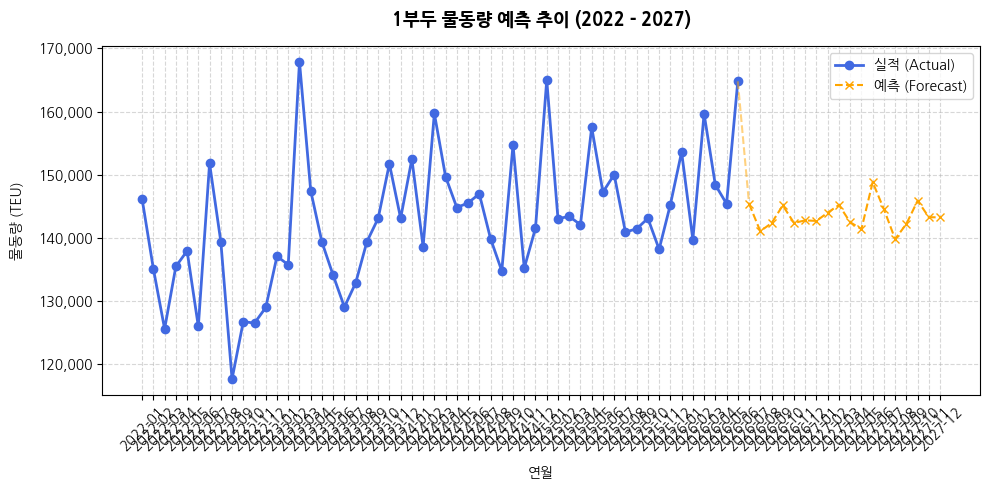

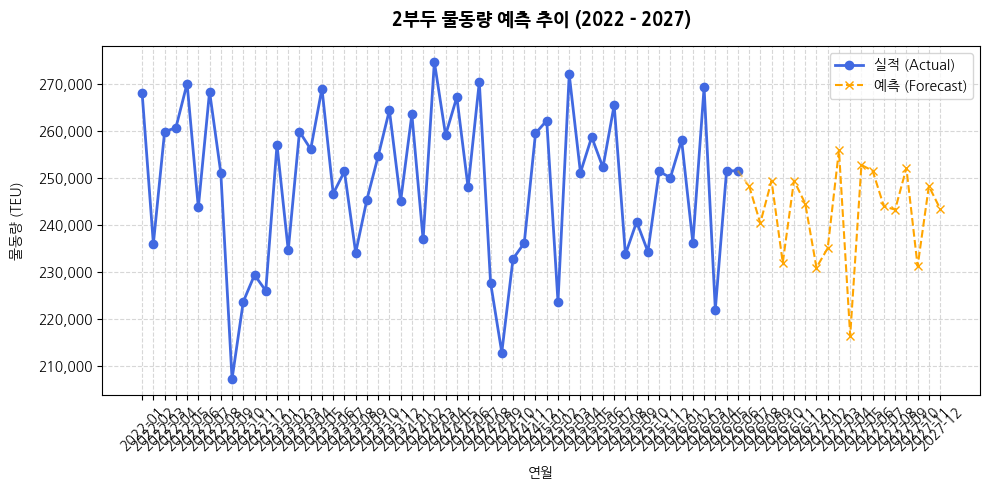

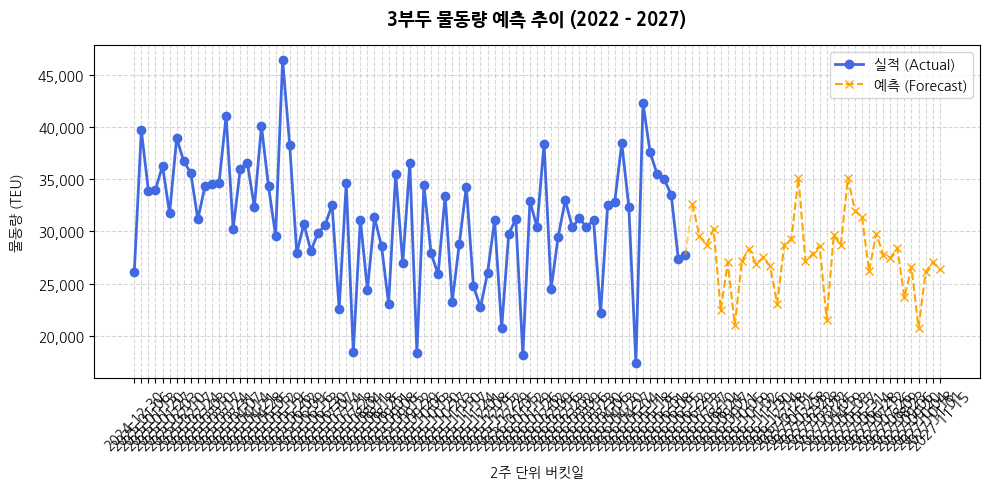

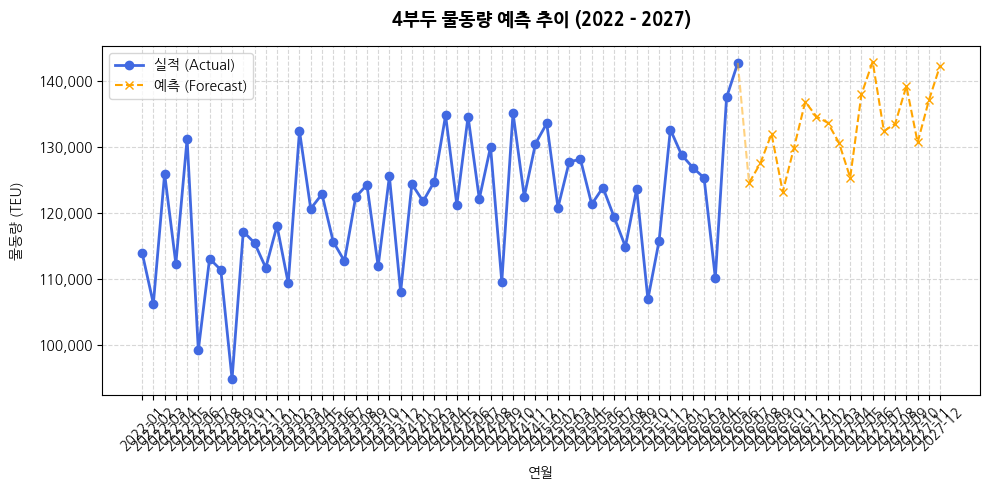

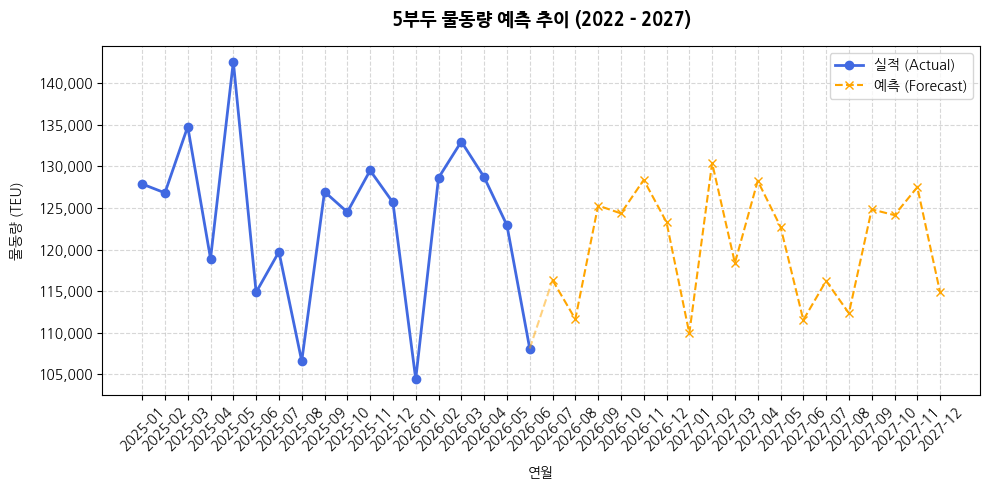

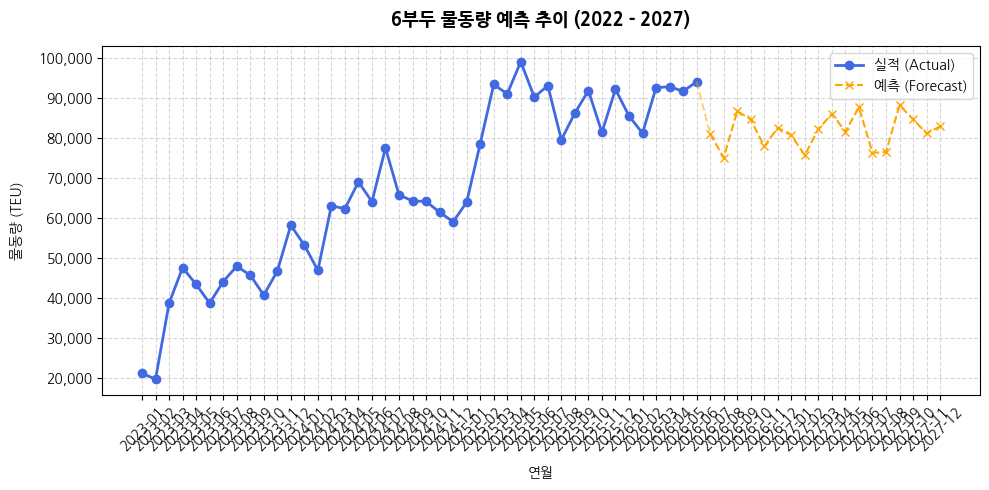

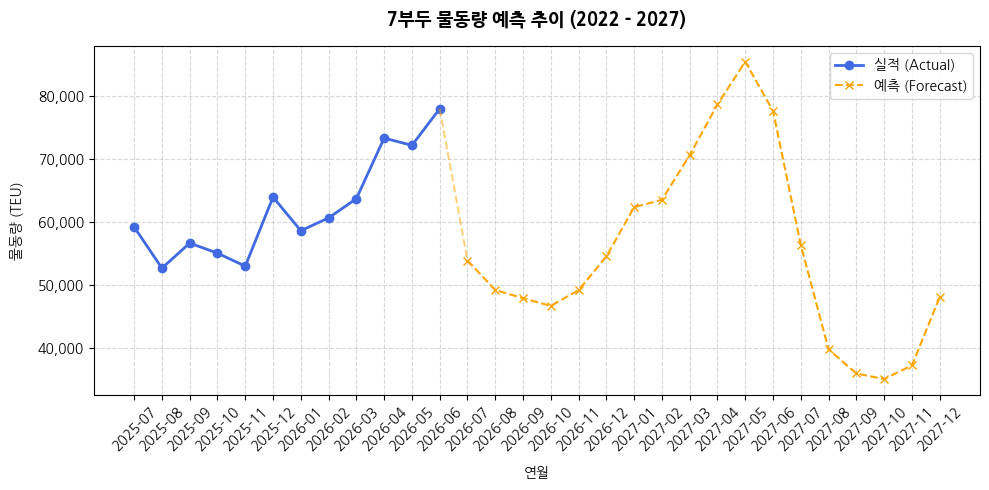

In [0]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

plt.rcParams['axes.unicode_minus'] = False

for budu, (actuals, forecasts) in plot_data.items():
    is_3budu = (budu == '3부두')
    actuals = actuals.sort_values(['연도', '월', '버킷기준일']).reset_index(drop=True)
    
    if is_3budu:
        actuals['Date'] = actuals['버킷기준일'].dt.strftime('%Y-%m-%d')
        pred_dates = []
        last_bucket_dt = actuals.iloc[-1]['버킷기준일']
        for m_idx in range(1, 37):
            curr_b = last_bucket_dt + pd.Timedelta(weeks=2 * m_idx)
            pred_dates.append(curr_b.strftime('%Y-%m-%d'))
    else:
        actuals['Date'] = actuals['연도'].astype(str) + '-' + actuals['월'].astype(str).str.zfill(2)
        pred_dates = []
        for m_idx in range(1, 19):
            yr, m = (2026, 6 + m_idx) if m_idx <= 6 else (2027, m_idx - 6)
            pred_dates.append(f"{yr}-{str(m).zfill(2)}")
            
    plt.figure(figsize=(10, 5))
    plt.plot(actuals['Date'], actuals['총물동량'], marker='o', label='실적 (Actual)', color='royalblue', linewidth=2)
    
    last_actual = actuals.iloc[-1]
    
    plt.plot([last_actual['Date'], pred_dates[0]], [last_actual['총물동량'], forecasts[0]], color='orange', linestyle='--', alpha=0.5)
    plt.plot(pred_dates, forecasts, marker='x', label="예측 (Forecast)", color='orange', linestyle='--')
        
    plt.title(f"{budu} 물동량 예측 추이 (2022 - 2027)", fontsize=13, weight='bold', pad=15)
    plt.xlabel("연월" if not is_3budu else "2주 단위 버킷일", labelpad=10)
    plt.ylabel("물동량 (TEU)", labelpad=10)
    plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    
    try:
        fig_path = f"/tmp/{budu}_forecast_plot.png"
        plt.savefig(fig_path, dpi=150, bbox_inches="tight")
        run_id = run_ids.get(budu)
        if run_id:
            with mlflow.start_run(run_id=run_id):
                mlflow.log_artifact(fig_path)
    except Exception as e:
        print(f"[로그] {budu} MLflow 차트 로깅 실패: {e}")
        
    plt.show()

In [0]:
# 상세 월별 예측/실적 피벗 테이블을 대시보드용 골드 테이블로 저장 (중복 방지를 위해 overwrite 모드 적용)
if 'df_monthly_pivot' in locals() and df_monthly_pivot is not None:
    spark_df = spark.createDataFrame(df_monthly_pivot)
    spark_df.write.format("delta").mode("overwrite").saveAsTable("dt4_project2_team3_databricks.gold.gold_forecast_output")
    print("[성공] 상세 월별 예측/실적 피벗 데이터가 gold_forecast_output 테이블에 정상 저장되었습니다.")
else:
    print("[경고] 저장할 상세 피벗 데이터(df_monthly_pivot)가 정의되지 않았습니다.")

[성공] 상세 월별 예측/실적 피벗 데이터가 gold_forecast_output 테이블에 정상 저장되었습니다.
